# Notebook de Optimización: Método de la Razón Dorada

Este cuaderno implementa el método de optimización de la Razón Dorada (Golden Section Search) para encontrar el mínimo de una función unimodal dentro de un intervalo especificado. Además, visualiza la función con el punto óptimo encontrado y la convergencia del error a lo largo de las iteraciones.

## ¿Qué es el Método de la Razón Dorada?

El método de la Razón Dorada es una técnica de búsqueda de optimización de una dimensión, similar a la búsqueda de la bisección, pero que utiliza la "razón dorada" (aproximadamente \(1.618\)) para reducir el intervalo de búsqueda de manera más eficiente. Es particularmente útil para funciones unimodales (funciones que tienen un solo mínimo o máximo en el intervalo) y no requiere el cálculo de derivadas.

El algoritmo funciona de la siguiente manera para encontrar un mínimo en el intervalo \([a, b]\):

1.  Se eligen dos puntos internos \(x_1\) y \(x_2\) dentro del intervalo \([a, b]\), utilizando la razón dorada.
2.  Se evalúa la función en \(f(x_1)\) y \(f(x_2)\).
3.  Si \(f(x_1) < f(x_2)\), el mínimo debe estar en el intervalo \([a, x_2]\), por lo que se descarta la parte derecha y se actualiza \(b = x_2\).
4.  Si \(f(x_1) > f(x_2)\), el mínimo debe estar en el intervalo \([x_1, b]\), por lo que se descarta la parte izquierda y se actualiza \(a = x_1\).
5.  Este proceso se repite hasta que el tamaño del intervalo \((b-a)\) sea menor que una tolerancia predefinida.

La ventaja de usar la razón dorada es que en cada iteración, uno de los puntos internos ya está correctamente posicionado para la siguiente iteración, lo que reduce los cálculos.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Aunque no es estrictamente necesario para el algoritmo, es útil para visualizar los datos del error.
import inspect

In [7]:
def funcion_ejemplo(x):
    return x**3 - x**2 - 10

In [9]:
def razon_dorada_minimizacion(func, a, b, tol=1e-5, max_iter=50):
    """
    Implementa el método de la Razón Dorada para encontrar el mínimo de una función.

    Args:
        func (callable): La función unimodal a minimizar.
        a (float): Límite inferior del intervalo de búsqueda.
        b (float): Límite superior del intervalo de búsqueda.
        tol (float): Tolerancia para el tamaño del intervalo de búsqueda.
        max_iter (int): Número máximo de iteraciones para evitar bucles infinitos.

    Returns:
        tuple: (x_opt, f_opt, historial_error)
               x_opt (float): El valor de x donde se encuentra el mínimo.
               f_opt (float): El valor de la función en x_opt.
               historial_error (list): Lista de tuplas (iteración, tamaño_intervalo)
                                       para graficar la convergencia del error.
    """
    
    # La razón dorada inversa, para calcular los puntos internos de manera eficiente
    phi_inv = (np.sqrt(5) - 1) / 2  # Aproximadamente 0.618034
    
    # Inicializar el historial de error
    historial_error = []
    
    # Calcular los primeros puntos internos
    x1 = b - phi_inv * (b - a)
    x2 = a + phi_inv * (b - a)
    
    f_x1 = func(x1)
    f_x2 = func(x2)
    
    # Guardar el estado inicial del error
    historial_error.append((0, b - a))

    for i in range(max_iter):
        if abs(b - a) < tol:
            break
        
        if f_x1 < f_x2:
            b = x2
            x2 = x1
            f_x2 = f_x1
            x1 = b - phi_inv * (b - a)
            f_x1 = func(x1)
        else:
            a = x1
            x1 = x2
            f_x1 = f_x2
            x2 = a + phi_inv * (b - a)
            f_x2 = func(x2)
            
        historial_error.append((i + 1, b - a))
        
    # El mínimo se encuentra aproximadamente en el centro del intervalo final
    x_opt = (a + b) / 2
    f_opt = func(x_opt)
    
    return x_opt, f_opt, historial_error

# Para encontrar el máximo, simplemente se puede minimizar la función negativa:
def razon_dorada_maximizacion(func, a, b, tol=1e-5, max_iter=1000):
    """
    Implementa el método de la Razón Dorada para encontrar el máximo de una función.
    Lo hace minimizando la función negativa.
    """
    def neg_func(x):
        return -func(x)
    
    x_opt, neg_f_opt, historial_error = razon_dorada_minimizacion(neg_func, a, b, tol, max_iter)
    f_opt = -neg_f_opt # Convertir el valor de la función negativa de vuelta al valor original
    
    return x_opt, f_opt, historial_error

In [16]:
# Definir el intervalo inicial de búsqueda
a_intervalo = 0.0
b_intervalo = 2.0
fn= inspect.getsource(funcion_ejemplo).split("return")[-1].strip()
# Definir la tolerancia
tolerancia = 1e-6

print(f"Buscando el mínimo de la función f(x) = {fn} en el intervalo [{a_intervalo}, {b_intervalo}]")
print(f"Con una tolerancia de {tolerancia}\n")

x_min_encontrado, f_min_encontrado, historial_error_min = razon_dorada_minimizacion(
    funcion_ejemplo, a_intervalo, b_intervalo, tol=tolerancia
)

print(f"Mínimo encontrado en x = {x_min_encontrado:.6f}")
print(f"Valor de la función en el mínimo = {f_min_encontrado:.6f}")
print(f"Número de iteraciones: {len(historial_error_min) - 1}") # Restamos 1 porque el historial incluye el estado inicial
print(f"Error final (tamaño del intervalo) = {historial_error_min[-1][1]:.6e}\n")

# Si quisiéramos encontrar el máximo (de una función unimodal en el intervalo):
# def funcion_ejemplo_max(x):
#     return -(x - 2)**2 + 5 # Función con máximo en x=2, f(2)=5
# x_max_encontrado, f_max_encontrado, historial_error_max = razon_dorada_maximizacion(
#     funcion_ejemplo_max, a_intervalo, b_intervalo, tol=tolerancia
# )
# print(f"Máximo encontrado en x = {x_max_encontrado:.6f}")
# print(f"Valor de la función en el máximo = {f_max_encontrado:.6f}")

Buscando el mínimo de la función f(x) = x**3 - x**2 - 10 en el intervalo [0.0, 2.0]
Con una tolerancia de 1e-06

Mínimo encontrado en x = 0.666667
Valor de la función en el mínimo = -10.148148
Número de iteraciones: 31
Error final (tamaño del intervalo) = 6.643748e-07



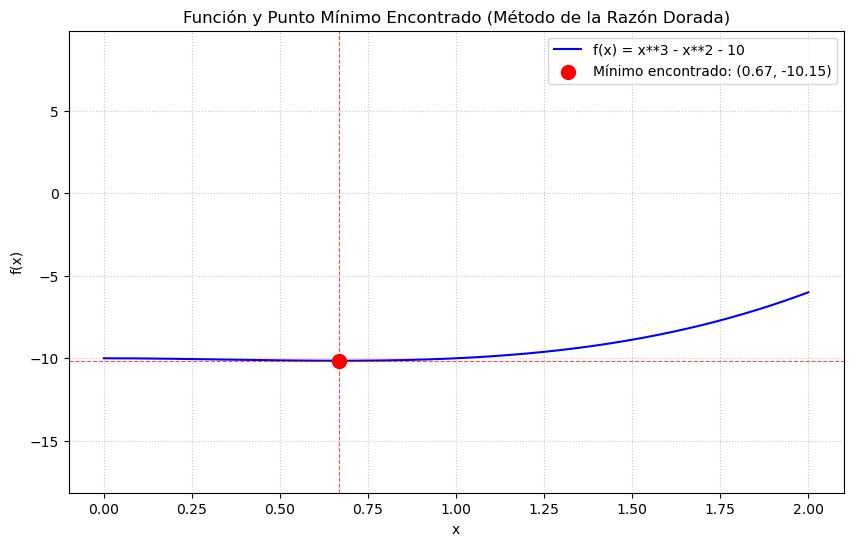

In [17]:
# Generar puntos para graficar la función
x_vals = np.linspace(a_intervalo, b_intervalo, 400)
y_vals = funcion_ejemplo(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = '+fn, color='blue')
plt.scatter(x_min_encontrado, f_min_encontrado, color='red', marker='o', s=100, 
            label=f'Mínimo encontrado: ({x_min_encontrado:.2f}, {f_min_encontrado:.2f})', zorder=5)
plt.axvline(x=x_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=f_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(f_min_encontrado - 8, f_min_encontrado + 20)
plt.title('Función y Punto Mínimo Encontrado (Método de la Razón Dorada)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

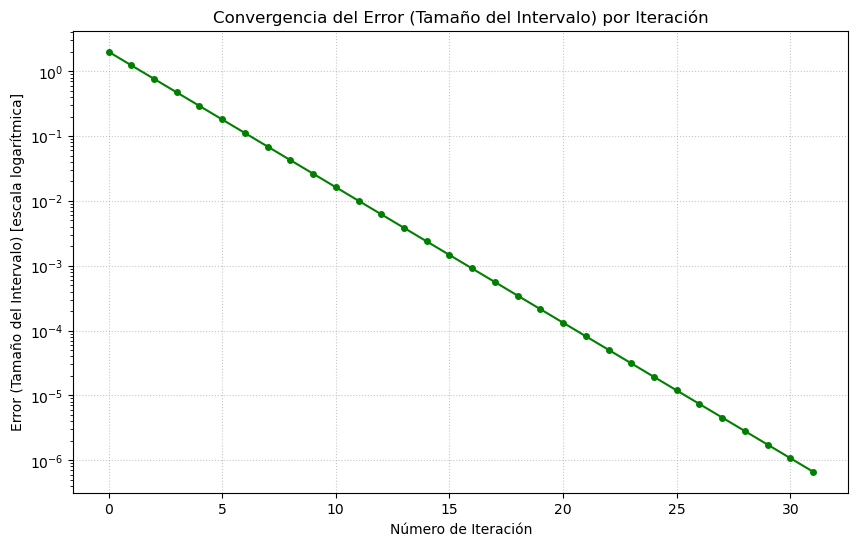

Historial de Error (primeras 10 y últimas 5 iteraciones):
   Iteración  Tamaño del Intervalo
0          0              2.000000
1          1              1.236068
2          2              0.763932
3          3              0.472136
4          4              0.291796
5          5              0.180340
6          6              0.111456
7          7              0.068884
8          8              0.042572
9          9              0.026311
...
    Iteración  Tamaño del Intervalo
27         27          4.553693e-06
28         28          2.814337e-06
29         29          1.739356e-06
30         30          1.074981e-06
31         31          6.643748e-07


In [18]:
# Extraer las iteraciones y los tamaños de intervalo del historial
iteraciones = [item[0] for item in historial_error_min]
errores = [item[1] for item in historial_error_min]

plt.figure(figsize=(10, 6))
plt.plot(iteraciones, errores, marker='o', linestyle='-', color='green', markersize=4)
plt.yscale('log') # Usar escala logarítmica para ver mejor la convergencia
plt.title('Convergencia del Error (Tamaño del Intervalo) por Iteración')
plt.xlabel('Número de Iteración')
plt.ylabel('Error (Tamaño del Intervalo) [escala logarítmica]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# También podemos mostrar los datos en una tabla para mayor detalle
df_error = pd.DataFrame(historial_error_min, columns=['Iteración', 'Tamaño del Intervalo'])
print("Historial de Error (primeras 10 y últimas 5 iteraciones):")
print(df_error.head(10))
print("...")
print(df_error.tail(5))

In [ ]:
# Tabla de iteraciones con formato estandar y legible
columnas = [
    'Iteración', 'x_k', 'y_k', 'f(x_k, y_k)',
    'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente'
]

filas = []

if 'historial' in globals() and historial:
    n_cols = len(historial[0])
    if n_cols == 9:
        for it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad in historial:
            filas.append([it, xk, yk, fk, dfx, dfy, h_opt, err, ngrad])
    elif n_cols == 4:
        for it, xk, gk, err in historial:
            filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])
    elif n_cols == 2:
        for it, err in historial:
            filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_raiz' in globals() and historial_raiz:
    for it, xk, gk, err in historial_raiz:
        filas.append([it, xk, np.nan, gk, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error_min' in globals() and historial_error_min:
    for it, err in historial_error_min:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

elif 'historial_error' in globals() and historial_error:
    for it, err in historial_error:
        filas.append([it, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, err, np.nan])

tabla = pd.DataFrame(filas, columns=columnas)

if tabla.empty:
    print('No se encontraron datos de historial para construir la tabla.')
else:
    tabla_fmt = tabla.copy()
    formato = {
        'x_k': '{:.6f}',
        'y_k': '{:.6f}',
        'f(x_k, y_k)': '{:.6f}',
        'df_dx': '{:.6f}',
        'df_dy': '{:.6f}',
        'h_opt': '{:.6f}',
        'Error_paso': '{:.3e}',
        'Norma_gradiente': '{:.3e}'
    }

    for col, fmt in formato.items():
        tabla_fmt[col] = tabla_fmt[col].map(lambda v: '' if pd.isna(v) else fmt.format(v))

    print('Tabla de iteraciones (valores y error):')
    print(tabla_fmt.to_string(index=False))